# SynapseMNIST 3D
von Yanni Alshoufi, Leo Breneis, Katharina Minihuber, Eros Klein, Melanie Dohr

Trainiert ein 3D-CNN auf dem SynapseMNIST3D Datensatz
(28x28x28 Voxel, binäre Klassifikation).

am 27.02.2026

## Load and explore the dataset

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC, Recall, Precision

DATA_DIR = "synapsemnist3d"

X_train = np.load(f"{DATA_DIR}/train_images.npy")
y_train = np.load(f"{DATA_DIR}/train_labels.npy")
X_val   = np.load(f"{DATA_DIR}/val_images.npy")
y_val   = np.load(f"{DATA_DIR}/val_labels.npy")
X_test  = np.load(f"{DATA_DIR}/test_images.npy")
y_test  = np.load(f"{DATA_DIR}/test_labels.npy")

print("=== Dataset Shapes ===")
print(f"Train:      images={X_train.shape}, labels={y_train.shape}")
print(f"Validation: images={X_val.shape},   labels={y_val.shape}")
print(f"Test:       images={X_test.shape},  labels={y_test.shape}")

=== Dataset Shapes ===
Train:      images=(1230, 28, 28, 28), labels=(1230, 1)
Validation: images=(177, 28, 28, 28),   labels=(177, 1)
Test:       images=(352, 28, 28, 28),  labels=(352, 1)


## Prepare the data

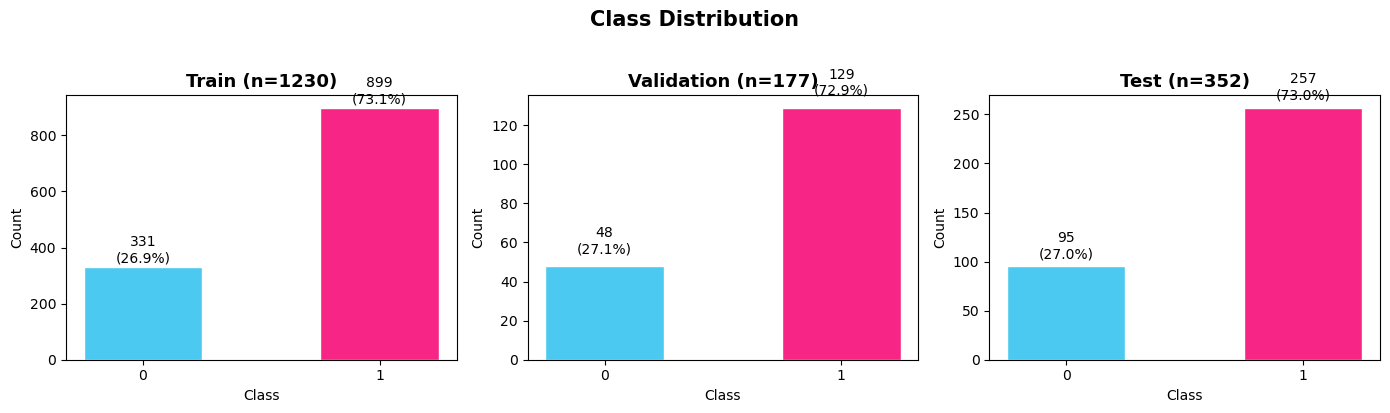

In [ ]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Flatten labels from (N, 1) to (N,) then one-hot encode
y_train_flat = y_train.flatten()
y_val_flat   = y_val.flatten()
y_test_flat  = y_test.flatten()

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, labels, title in zip(axes, [y_train, y_val, y_test], ["Train", "Validation", "Test"]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = ["#4cc9f0", "#f72585"]
    bars = ax.bar(unique, counts, color=colors[:len(unique)], edgecolor="white", width=0.5)
    ax.set_title(f"{title} (n={len(labels)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(unique)
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, labels, title in zip(axes, [y_train, y_val, y_test], ["Train", "Validation", "Test"]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = ["#4cc9f0", "#f72585"]
    bars = ax.bar(unique, counts, color=colors[:len(unique)], edgecolor="white", width=0.5)
    ax.set_title(f"{title} (n={len(labels)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(unique)
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Build and train a 3D CNN

In [18]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.flatten())
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.8580060422960725), 1: np.float64(0.6840934371523916)}


In [19]:
# Add channel dimension: (N, 28, 28, 28) -> (N, 28, 28, 28, 1)
X_train_3d = X_train[..., np.newaxis]
X_val_3d   = X_val[..., np.newaxis]
X_test_3d  = X_test[..., np.newaxis]

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 28, 1)),

    layers.Conv3D(32, (3, 3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling3D((2, 2, 2)),

    layers.Conv3D(64, (3, 3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling3D((2, 2, 2)),

    layers.GlobalAveragePooling3D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    restore_best_weights=True,
    patience=7,
)

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="auc"),
        Recall(name="recall"),
        Precision(name="precision"),
    ],
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_3d, y_train_flat,
    validation_data=(X_val_3d, y_val_flat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict, 
    verbose=1,
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_6 (Conv3D)               │ (None, 28, 28, 28, 32) │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 28, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 14, 14, 14, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 14, 14, 14, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 14, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 7, 7, 7, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,865 (237.75 KB)

 Trainable params: 60,673 (237.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.5626 - auc: 0.5904 - loss: 0.7050 - precision: 0.7861 - recall: 0.5517 - val_accuracy: 0.2712 - val_auc: 0.4846 - val_loss: 0.7468 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.6447 - auc: 0.6653 - loss: 0.6485 - precision: 0.8016 - recall: 0.6830 - val_accuracy: 0.2712 - val_auc: 0.4926 - val_loss: 0.7891 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - accuracy: 0.6496 - auc: 0.6739 - loss: 0.6436 - precision: 0.8214 - recall: 0.6652 - val_accuracy: 0.2712 - val_auc: 0.5395 - val_loss: 0.7715 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.6780 - auc: 0.7143 - loss: 0.6203 - precision: 0.8431 - recall: 0.6874 - val_accuracy: 0.5989 - val_auc: 0.5674 - val_loss: 0.6886 - val_precision: 0.7685 - val_recall: 0.6434
E

## Evaluation

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8097 - auc: 0.7985 - loss: 0.6357 - precision: 0.8519 - recall: 0.8949
Test – Loss: 0.6357, Accuracy: 0.8097, AUC: 0.7985, Recall: 0.8949, Precision: 0.8519


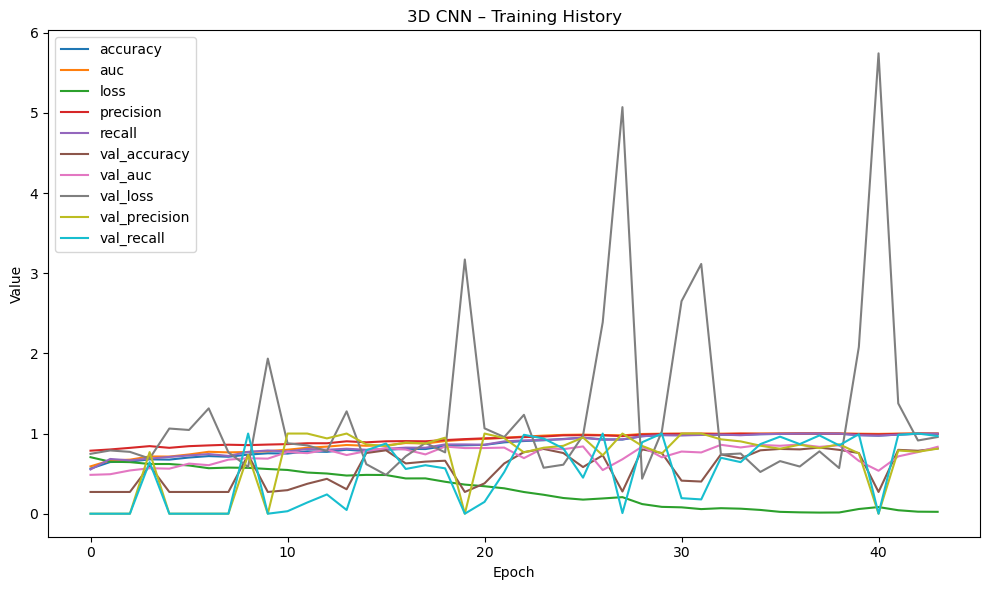

In [21]:
cnn_loss, cnn_acc, cnn_auc, cnn_recall, cnn_precision = cnn_model.evaluate(X_test_3d, y_test_flat, verbose=1)
print(f"Test – Loss: {cnn_loss:.4f}, Accuracy: {cnn_acc:.4f}, AUC: {cnn_auc:.4f}, Recall: {cnn_recall:.4f}, Precision: {cnn_precision:.4f}")

import pandas as pd

fig, ax = plt.subplots(figsize=(10, 6))
pd.DataFrame(cnn_history.history).plot(ax=ax)
ax.set_title("3D CNN – Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("cnn_3d_history.png", dpi=150)
plt.show()